In [1]:
%pip install seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

In [3]:
iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="species")

df = X.copy()
df["species"] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nClass counts:")
print(df["species"].value_counts())

Dataset shape: (150, 5)

Column names:
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species'],
      dtype='str')

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Class counts:
species
0    50
1    50
2    50
Name: count, dtype: int64


In [5]:
print("0 =", iris.target_names[0])
print("1 =", iris.target_names[1])
print("2 =", iris.target_names[2])

0 = setosa
1 = versicolor
2 = virginica


In [6]:
df.to_csv("Iris_Dataset.csv", index=False)

print("Dataset saved successfully as Iris_Dataset.csv")

Dataset saved successfully as Iris_Dataset.csv


In [7]:
import os
print(os.getcwd())

C:\Users\nspgr


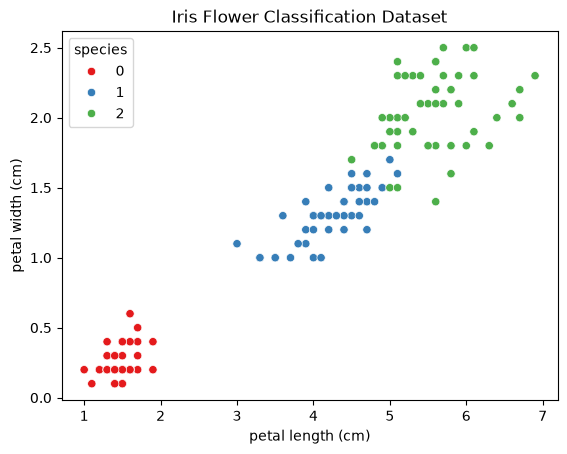

In [8]:
sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species",
    palette="Set1"
)

plt.title("Iris Flower Classification Dataset")
plt.show()

In [9]:
X = df.drop("species", axis=1)
y = df["species"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target:
0    0
1    0
2    0
3    0
4    0
Name: species, dtype: int64


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (120, 4)
Testing data shape: (30, 4)


In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
logistic_model = LogisticRegression(max_iter=200)

logistic_model.fit(X_train_scaled, y_train)

logistic_predictions = logistic_model.predict(X_test_scaled)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [13]:
logistic_accuracy = accuracy_score(y_test, logistic_predictions)

print("Logistic Regression Accuracy:", logistic_accuracy)
print("Logistic Regression Accuracy Percentage:", logistic_accuracy * 100, "%")

Logistic Regression Accuracy: 0.9333333333333333
Logistic Regression Accuracy Percentage: 93.33333333333333 %


In [14]:
print("Precision:", precision_score(y_test, logistic_predictions, average="weighted"))
print("Recall:", recall_score(y_test, logistic_predictions, average="weighted"))

print("\nClassification Report:")
print(classification_report(y_test, logistic_predictions, target_names=iris.target_names))

Precision: 0.9333333333333333
Recall: 0.9333333333333333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



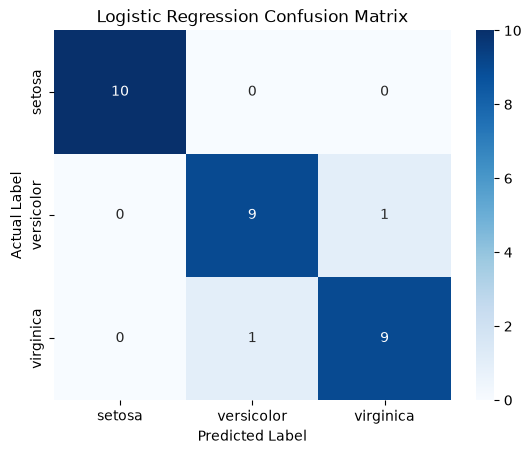

In [15]:
logistic_cm = confusion_matrix(y_test, logistic_predictions)

sns.heatmap(
    logistic_cm,
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [16]:
tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [17]:
tree_accuracy = accuracy_score(y_test, tree_predictions)

print("Decision Tree Accuracy:", tree_accuracy)
print("Decision Tree Accuracy Percentage:", tree_accuracy * 100, "%")

Decision Tree Accuracy: 0.9333333333333333
Decision Tree Accuracy Percentage: 93.33333333333333 %


In [18]:
print("Precision:", precision_score(y_test, tree_predictions, average="weighted"))
print("Recall:", recall_score(y_test, tree_predictions, average="weighted"))

print("\nClassification Report:")
print(classification_report(y_test, tree_predictions, target_names=iris.target_names))

Precision: 0.9333333333333333
Recall: 0.9333333333333333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



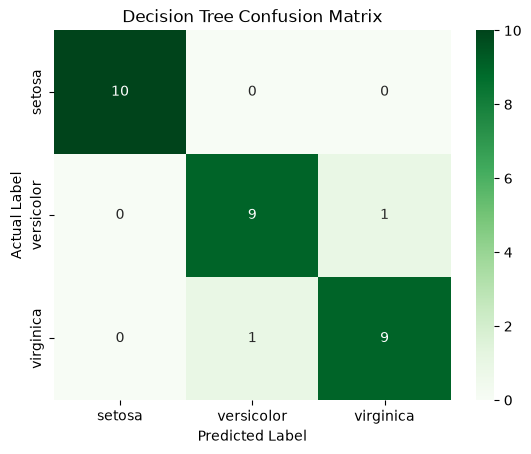

In [19]:
tree_cm = confusion_matrix(y_test, tree_predictions)

sns.heatmap(
    tree_cm,
    annot=True,
    cmap="Greens",
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

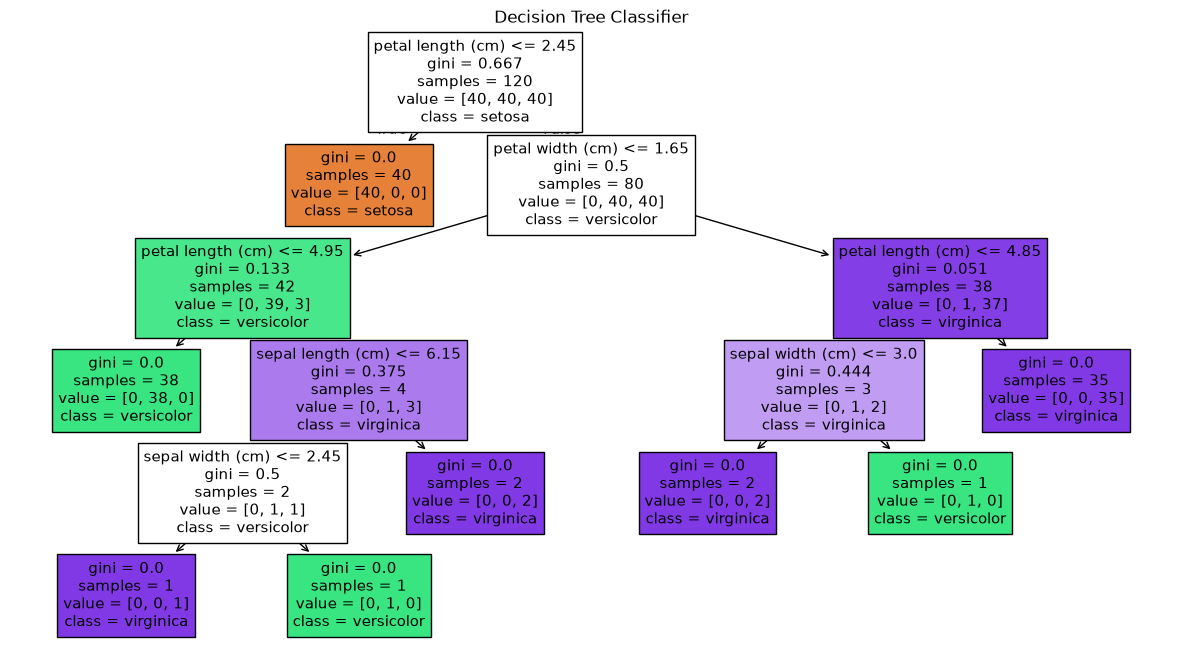

In [20]:
plt.figure(figsize=(15, 8))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=iris.target_names,
    filled=True
)

plt.title("Decision Tree Classifier")
plt.show()

In [21]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [logistic_accuracy, tree_accuracy],
    "Accuracy Percentage": [logistic_accuracy * 100, tree_accuracy * 100]
})

comparison

,Model,Accuracy,Accuracy Percentage
0,Logistic Regression,0.933333,93.333333
1,Decision Tree,0.933333,93.333333


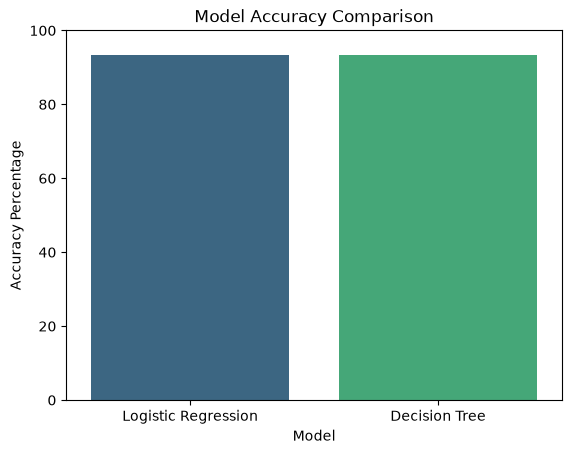

In [25]:
sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy Percentage",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.title("Model Accuracy Comparison")
plt.ylim(0, 100)
plt.ylabel("Accuracy Percentage")
plt.show()

In [26]:
print("Model Comparison:")
print(comparison)

if logistic_accuracy == tree_accuracy:
    print("\nConclusion:")
    print("Both models achieved identical accuracy (93.33%) on this dataset.")
    print("In case of a tie, other factors like model interpretability,")
    print("training speed, or performance on a larger dataset can help decide between them.")
    print("Decision Trees are easier to visualize and explain, while Logistic")
    print("Regression tends to generalize better on larger, more complex datasets.")
else:
    best_model = comparison.loc[comparison["Accuracy"].idxmax(), "Model"]
    print("\nBest performing model:", best_model)

print("Results may change if the train-test split or random state is changed.")

Model Comparison:
                 Model  Accuracy  Accuracy Percentage
0  Logistic Regression  0.933333            93.333333
1        Decision Tree  0.933333            93.333333

Conclusion:
Both models achieved identical accuracy (93.33%) on this dataset.
In case of a tie, other factors like model interpretability,
training speed, or performance on a larger dataset can help decide between them.
Decision Trees are easier to visualize and explain, while Logistic
Regression tends to generalize better on larger, more complex datasets.
Results may change if the train-test split or random state is changed.
